In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.sandbox.stats.multicomp import multipletests
import os
import matplotlib.pylab as pylab
import matplotlib as mpl
import warnings

warnings.filterwarnings("ignore")
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 7,
    'axes.titlesize': 7,
    'axes.labelsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'figure.titlesize': 7,
    'figure.dpi': 200,
    'axes.linewidth': 0.7,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial',
    'mathtext.it': 'Arial:italic',
    'mathtext.bf': 'Arial:bold',
})

In [12]:
associate_df = pd.read_csv('./data/ukb.RDH_burden.WBnR.association.continu.MSA-MTR_0.649_AF0.001.tsv', sep='\t')
associate_df['p_bonferroni'] = associate_df['p_value'].apply(lambda x: min(x * 9, 1.0))

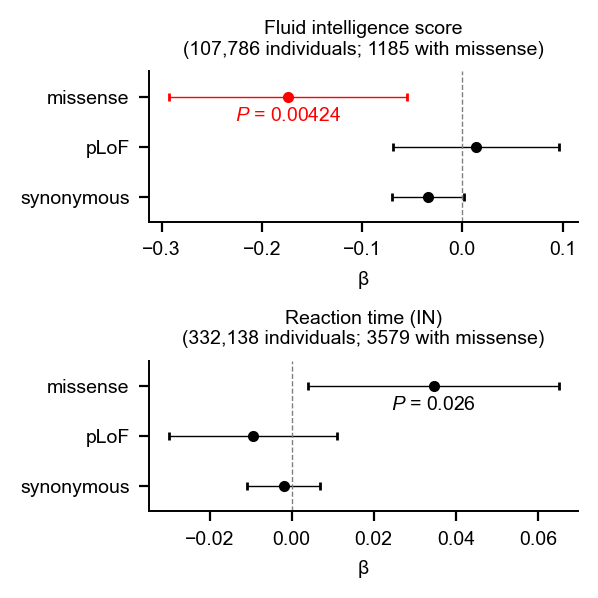

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(3, 3))
axes = axes.flatten()

for idx, phenotype in enumerate([
    'Fluid intelligence',
    'Reaction time (IN)'
]):

    sub_df = associate_df[associate_df['phenotype'] == phenotype].copy()
    y_pos = np.arange(len(sub_df))

    axes[idx].set_yticks(y_pos)
    axes[idx].set_yticklabels(sub_df["variable"])

    for i, row in enumerate(sub_df.itertuples()):
        x = row.beta
        left_error = x - row.ci_lower
        right_error = row.ci_upper - x

        sig = row.p_bonferroni < 0.05
        color = 'red' if sig else 'black'

        axes[idx].errorbar(
            x, y_pos[i],
            xerr=[[left_error], [right_error]],
            fmt='o',
            color=color,
            capsize=1.5,
            linewidth=0.5,
            markersize=3
        )

        if row.p_value < 0.05:
            axes[idx].text(
                x,
                y_pos[i] + 0.2,
                fr'$P$ = {row.p_value:.3g}',
                va='top',
                ha='center',
                fontsize=7,
                color=color
            )

    axes[idx].axvline(0, color='gray', linestyle='--', linewidth=0.5)
    axes[idx].set_xlabel('β')

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_ylim(-0.5, 2.5)
    ax.invert_yaxis()

axes[0].set_title('Fluid intelligence score\n(107,786 individuals; 1185 with missense)')
axes[1].set_title('Reaction time (IN)\n(332,138 individuals; 3579 with missense)')

plt.tight_layout()